# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [2]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝
for name, model in base_models.items():
    # Вычисляем 5-fold CV
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    
    # Сохраняем среднее и стандартное отклонение
    baseline_results[name] = {
        'mean': np.mean(cv_scores),
        'std': np.std(cv_scores)
    }
# После заполнения — вывод результатов:
for name, stats in baseline_results.items():
    mean = stats['mean']
    std = stats['std']
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")


SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [4]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                         ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    # YOUR CODE HERE
    'svm__kernel' : ['poly','rbf','linear'],
    'svm__gamma' : ['scale', 0.01, 0.001],
    'svm__C' : [0.1, 1, 10, 100],
}
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, cv =5, scoring = 'f1_macro', n_jobs =-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [5]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
results_df = pd.DataFrame(svm_grid_search.cv_results_)
results_df = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_df = results_df.sort_values('rank_test_score')
print("Топ-10 конфигураций:")
results_df.head(10)

Топ-10 конфигураций:


,params,mean_test_score,std_test_score,rank_test_score
22,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
2,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
8,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
34,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
25,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
10,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
19,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
31,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
27,"{'svm__C': 100, 'svm__gamma': 'scale', 'svm__k...",0.966876,0.011809,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform
from sklearn.ensemble import RandomForestClassifier
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    # YOUR CODE HERE
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(RandomForestClassifier(ccp_alpha=0.2, random_state=42), rf_param_dist, n_iter=36, scoring = 'f1_macro', n_jobs=-1, cv=5,random_state=42)
rf_random_search.fit(X_train, y_train)
print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 17, 'max_features': 'sqrt', 'min_samples_split': 19, 'n_estimators': 416}
Лучший CV F1: 0.9200


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [7]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_cool = svm_grid_search.best_estimator_
rf_cool = rf_random_search.best_estimator_
svm_preds = svm_cool.predict(X_test)
rf_preds = rf_cool.predict(X_test)
from sklearn.metrics import classification_report
print('svm:', classification_report(y_test, svm_preds))
print('rf: ', classification_report(y_test, rf_preds))
svm_baseline = base_models['SVM']
rf_baseline = base_models['RandomForest']
svm_baseline.fit(X_train, y_train)
rf_baseline.fit(X_train, y_train)
svm_baseline_score = svm_baseline.predict(X_test)
rf_baseline_score = rf_baseline.predict(X_test)
print('svm baseline score:', f1_score(y_test, svm_baseline_score))
print('rf baseline score:', f1_score(y_test, rf_baseline_score))
# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |        0.97      |  0.98   |
# | SVM Grid Search       |       0.978      |  0.98   |
# | RF baseline           |       0.95       |   0.965 |
# | RF Random Search      |        0.92      |   0.93  |

svm:               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

rf:                precision    recall  f1-score   support

           0       0.93      0.88      0.90        42
           1       0.93      0.96      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

svm baseline score: 0.9861111111111112
rf baseline score: 0.9655172413793104


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

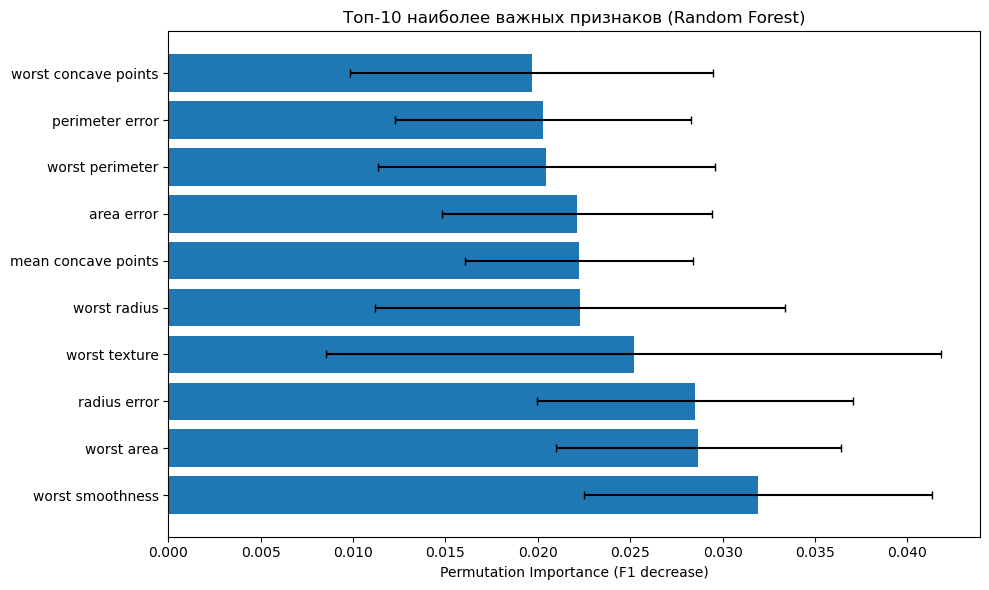

In [8]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
pi_result = permutation_importance(svm_cool, X_test, y_test, scoring='f1_macro', random_state=42, n_repeats=10)

# Построим bar plot топ-10 признаков
# YOUR CODE HERE
# Построим bar plot топ-10 признаков
# Берём средние важности
importances = pi_result.importances_mean
std = pi_result.importances_std

# Индексы для сортировки (по убыванию важности)
indices = np.argsort(importances)[::-1]

# Топ-10
top_n = 10
indices_top = indices[:top_n]

# Названия признаков (если X_test — DataFrame)
feature_names = X_test.columns if hasattr(X_test, 'columns') else [f"Feature {i}" for i in range(X_test.shape[1])]

# Построение графика
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importances[indices_top][::-1], xerr=std[indices_top][::-1], capsize=3)
plt.yticks(range(top_n), [feature_names[i] for i in indices_top[::-1]])
plt.xlabel("Permutation Importance (F1 decrease)")
plt.title("Топ-10 наиболее важных признаков (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Топ-5 признаков по Permutation Importance:
             Feature  Permutation Importance
24  worst smoothness                0.031914
23        worst area                0.028691
10      radius error                0.028494
21     worst texture                0.025182
20      worst radius                0.022273

Топ-5 признаков по Built-in Importance:
                 Feature  Built-in Importance
23            worst area             0.155039
22       worst perimeter             0.147287
27  worst concave points             0.126615
7    mean concave points             0.103359
20          worst radius             0.098191

Совпадают ли топ-5?
Нет


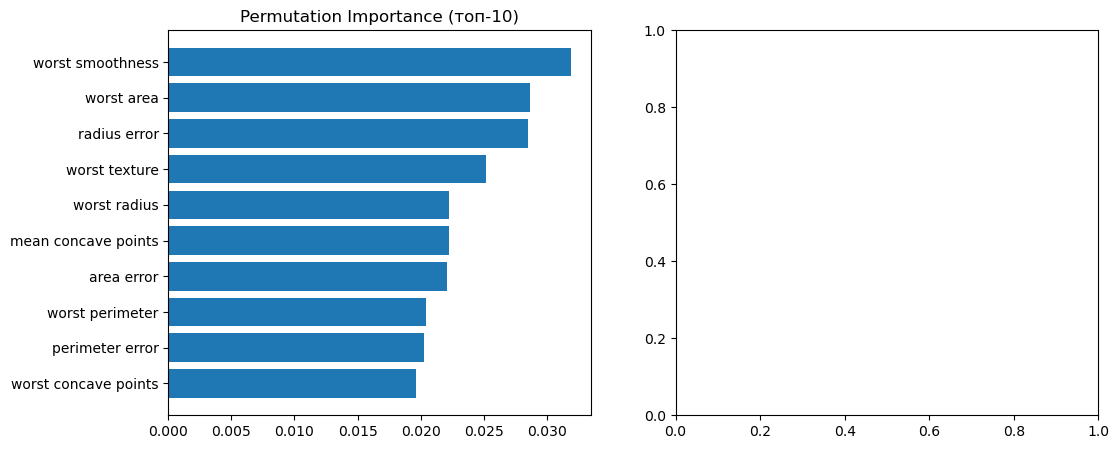

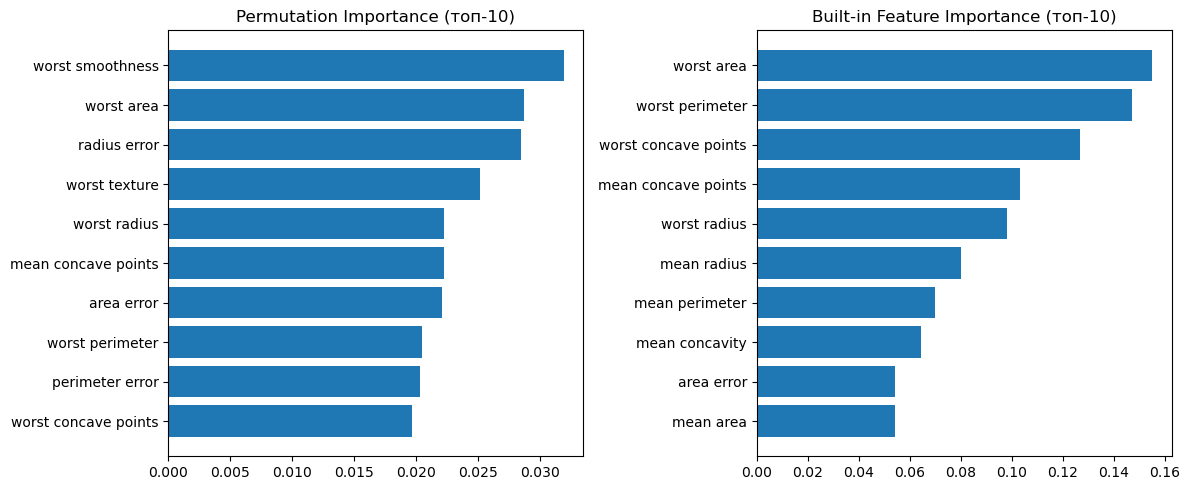

<Figure size 640x480 with 0 Axes>

In [9]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝
#тут хуйня
# YOUR CODE HERE
rf_importances = rf_cool.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Permutation Importance': pi_result.importances_mean,
    'Built-in Importance': rf_importances
})

importance_df = importance_df.sort_values('Permutation Importance', ascending=False)

print("Топ-5 признаков по Permutation Importance:")
print(importance_df[['Feature', 'Permutation Importance']].head(5))

print("\nТоп-5 признаков по Built-in Importance:")
print(importance_df.sort_values('Built-in Importance', ascending=False)[['Feature', 'Built-in Importance']].head(5))

top5_perm = importance_df.head(5)['Feature'].values
top5_builtin = importance_df.sort_values('Built-in Importance', ascending=False).head(5)['Feature'].values

print("\nСовпадают ли топ-5?")
print("Да" if set(top5_perm) == set(top5_builtin) else "Нет")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(importance_df['Feature'][:10], importance_df['Permutation Importance'][:10])
axes[0].set_title('Permutation Importance (топ-10)')
axes[0].invert_yaxis()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Permutation Importance': pi_result.importances_mean,
    'Built-in Importance': rf_cool.feature_importances_
})

importance_df_perm = importance_df.sort_values('Permutation Importance', ascending=False)
ax1.barh(importance_df_perm['Feature'][:10], importance_df_perm['Permutation Importance'][:10])
ax1.set_title('Permutation Importance (топ-10)')
ax1.invert_yaxis()

importance_df_builtin = importance_df.sort_values('Built-in Importance', ascending=False)
ax2.barh(importance_df_builtin['Feature'][:10], importance_df_builtin['Built-in Importance'][:10])
ax2.set_title('Built-in Feature Importance (топ-10)')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

importance_df_sorted = importance_df.sort_values('Built-in Importance', ascending=False)
axes[1].barh(importance_df_sorted['Feature'][:10], importance_df_sorted['Built-in Importance'][:10])
axes[1].set_title('Built-in Feature Importance (топ-10)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?
#встроенная важность определяется тем как часто дерево использует этот признак в разбиении,
#а PI проверяет как сильно признак влияет на метрику качества. оказывается что высокий gini != сильное влияние на метрику качества

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

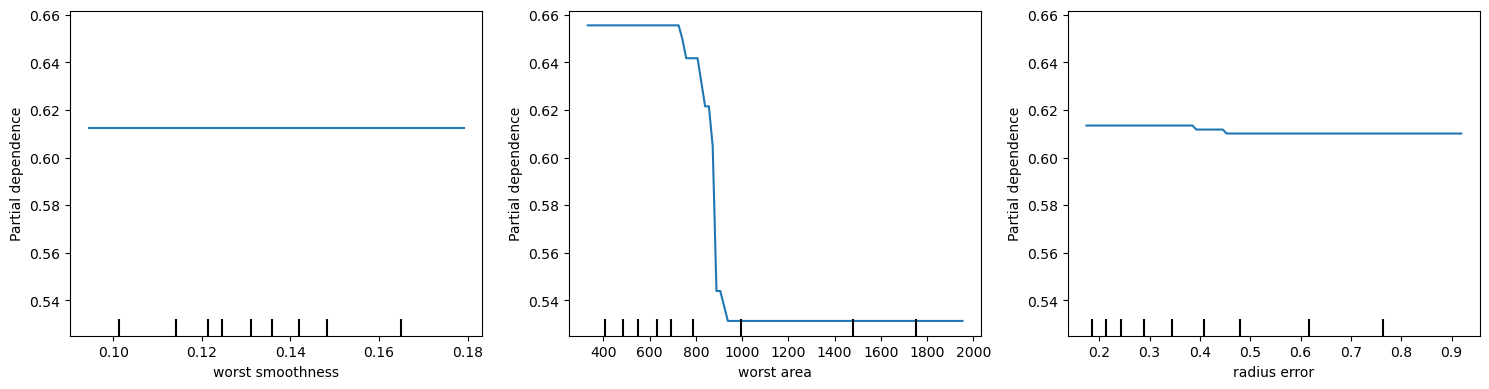

Топ-3 признака по PI:
1. worst smoothness (PI = 0.0319)
2. worst area (PI = 0.0287)
3. radius error (PI = 0.0285)


In [10]:
from sklearn.inspection import PartialDependenceDisplay

# Определите индексы топ-3 признаков по PI
top3_idx = np.argsort(pi_result.importances_mean)[::-1][:3]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

PartialDependenceDisplay.from_estimator(
    best_rf, X_test, top3_idx,
    kind='average', ax=ax, 
    feature_names=X.columns
)

plt.tight_layout()
plt.show()

# Выведите названия признаков
print("Топ-3 признака по PI:")
for i, idx in enumerate(top3_idx):
    print(f"{i+1}. {X.columns[idx]} (PI = {pi_result.importances_mean[idx]:.4f})")

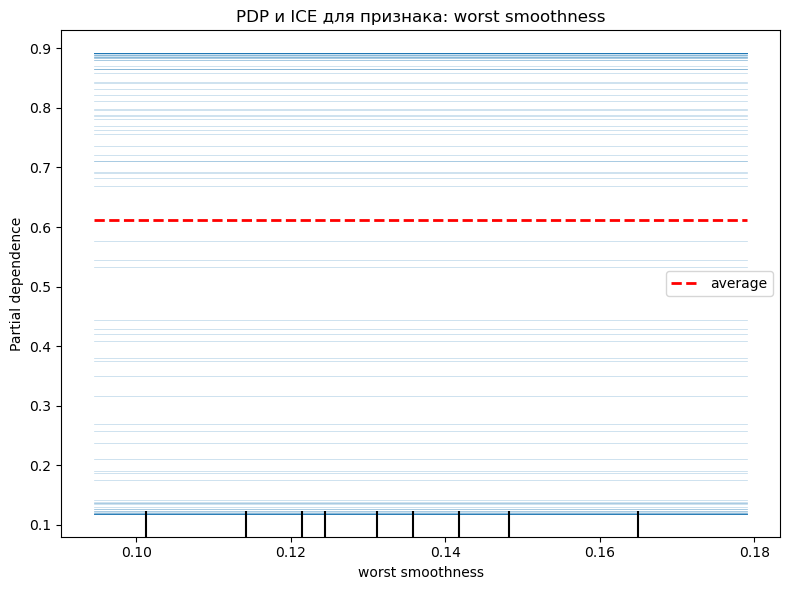

In [11]:
# 7б: ICE-кривые для самого важного признака
# Берём индекс самого важного признака по PI
top1_idx = top3_idx[0]

# Строим график с PDP + ICE
fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    best_rf, X_test, [top1_idx],
    kind='both',           # PDP + все ICE кривые
    ax=ax,
    feature_names=X.columns,
    ice_lines_kw={'linewidth': 0.5, 'alpha': 0.3},
    pd_line_kw={'linewidth': 2, 'color': 'red'}
)

ax.set_title(f'PDP и ICE для признака: {X.columns[top1_idx]}')
plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [12]:
import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(rf_cool)
shap_values = explainer.shap_values(X_test)


print(f"Форма shap_values: {shap_values.shape}")

Форма shap_values: (114, 30, 2)


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [13]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Точность на тесте: 0.9912


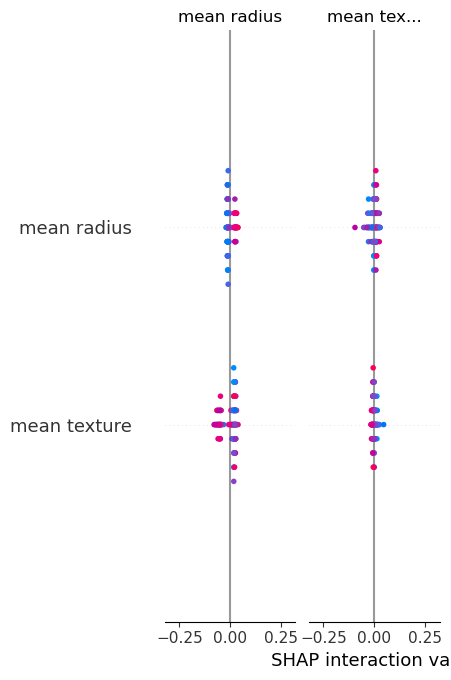

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝
from sklearn.metrics import accuracy_score
# YOUR CODE HERE
rf_shap = RandomForestClassifier(random_state=42, n_estimators=76, max_depth=8)
rf_shap.fit(X_train_ext, y_train)

preds_shap_rf = rf_shap.predict(X_test_ext)
print(f"Точность на тесте: {accuracy_score(y_test, preds_shap_rf):.4f}")

pi_ext = permutation_importance(
    rf_shap, X_test_ext, y_test,
    n_repeats=10, random_state=42, scoring='f1_macro'
)



explainer_shap = shap.TreeExplainer(rf_shap)
shap_values_ext = explainer_shap.shap_values(X_test_ext)

shap.summary_plot(shap_values_ext[1] if isinstance(shap_values_ext, list) else shap_values_ext, 
                  X_test_ext, feature_names=X_test_ext.columns)

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |   0.85 |  0.83   |                     | ║
# ║  | SVM Grid Search|  0.93  | 0.91    |                     | ║
# ║  | RF baseline    |    0.86|   0.84  |                     | ║
# ║  | RF Rand Search |    0.93| 0.92    |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
#1 неплохо улучшил
#2 не всегда но в целом да. 
#3 пришлось бы вручную масштабировать данные 
#4 PI для проверки какие признаки обьективно с человеческой точки зрения полезны
#  а какие нет. SHAP для того чтобы показать для конкретного обьекта датасета почему мы приняли такое решение

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [16]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")